# Chunking Goldilocks: TechQA (RAGBench)

Same three-phase chunking search methodology as `delucion_dataset/11_chunking_goldilocks.ipynb`,
applied fresh to a different RAGBench component dataset: **TechQA** (customer-support,
tech-forum Q&A -- RAGBench's `techqa` config). Reuses the shared `ragbench_lib` package from
`delucion_dataset/ragbench_lib` rather than duplicating it -- both dataset folders share one
library, one TRACe implementation, one set of bug fixes, so a fix made in one place benefits
every dataset folder that imports it.

**Nothing here inherits DelucionQA's answers.** TechQA's source documents are tech-support
forum posts and replies, not short owner's-manual sections -- likely longer, more
conversational, and less uniformly single-fact than DelucionQA's Jeep Gladiator manual
excerpts (the property `delucion_dataset/CHUNKING_GOLDILOCKS_ANALYSIS.md` found explained
DelucionQA's small-chunk, single-fact preference). Whether the same chunking method, size, or
overlap wins here is exactly what this notebook exists to find out, not assume -- the winning
config discovered below feeds `12_retriever_goldilocks.ipynb` for TechQA, exactly as `11`'s
DelucionQA winner fed `delucion_dataset/12_retriever_goldilocks.ipynb`.

Same rigor as the DelucionQA series: a fixed 20-question evaluation set reused across every
config in every phase, judge annotation retries instead of silently dropping failures, and a
documented composite score (0.35·Relevance + 0.15·Utilization + 0.15·Completeness +
0.35·Adherence) instead of optimizing on Context Relevance alone.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    """ragbench_lib physically lives under delucion_dataset/ -- shared, not
    duplicated, across every dataset folder in this repo. Checks several
    plausible cwd's so this works whether the notebook is launched from the
    repo root or from within techqa_dataset/ itself."""
    here = os.getcwd()
    candidates = (
        here,
        os.path.join(here, "delucion_dataset"),
        os.path.join(os.path.dirname(here), "delucion_dataset"),
        os.path.join(here, "..", "delucion_dataset"),
    )
    for candidate in candidates:
        candidate = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return
    raise RuntimeError("Could not locate the shared ragbench_lib package (expected under delucion_dataset/).")


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.vector_store import get_persist_dir, vector_store_names
from ragbench_lib.chunking import count_tokens, get_sentences, encoding, create_semantic_chunks
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset (fixed evaluation set)

`EVAL_SAMPLE_SIZE` questions are chosen **once**, up front, and reused for every single
config below -- Phase 1, 2, and 3 all score against the exact same questions, so
differences between configs reflect the chunking choice, not sampling luck.

In [3]:
DATASET_NAME = "techqa"  # feeds load_rag_bench_data() and vector store naming -- RAGBench's tech-forum Q&A config
EVAL_SAMPLE_SIZE = 20        # fixed across every config in this notebook

print("Loading dataset...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 30))
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed evaluation set: {len(eval_questions_df)} unique questions (reused for every config below)")


Loading dataset...


Generating test split: 100%|██████████| 314/314 [00:00<00:00, 17437.62 examples/s]


✓ Loaded 150 documents from 30 unique questions
✓ Fixed evaluation set: 20 unique questions (reused for every config below)


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, and judge configured")


✓ Embedding model, generator, and judge configured


## Step 5: Chunking Method Implementations

In [5]:
def token_level_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """Raw token-count cuts. Can split mid-sentence."""
    overlap_tokens = int(target_tokens * overlap_fraction)
    documents = []
    for _, doc in docs_df.iterrows():
        tokens = encoding.encode(doc["text"])
        i, chunk_idx = 0, 0
        while i < len(tokens):
            chunk_text = encoding.decode(tokens[i : i + target_tokens])
            if chunk_text.strip():
                documents.append(Document(
                    page_content=chunk_text,
                    metadata={
                        "chunk_id": f"{doc['doc_id']}_tok{chunk_idx}",
                        "row_id": doc["row_id"],
                        "tokens": count_tokens(chunk_text),
                    },
                ))
                chunk_idx += 1
            i += max(target_tokens - overlap_tokens, 1)
    return documents


print("✓ token_level_chunks defined")


✓ token_level_chunks defined


In [6]:
def sentence_level_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """Group whole sentences up to target_tokens; overlap carries the last
    overlap_fraction of each chunk's sentences into the next chunk. Fixes a bug in
    03's version, where overlap_fraction was computed but never actually applied."""
    documents = []
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        if not sentences:
            continue
        sent_tokens = [count_tokens(s) for s in sentences]
        n = len(sentences)
        i, chunk_idx = 0, 0
        while i < n:
            chunk_sents, chunk_tok_count, j = [], 0, i
            while j < n and (not chunk_sents or chunk_tok_count + sent_tokens[j] <= target_tokens):
                chunk_sents.append(sentences[j])
                chunk_tok_count += sent_tokens[j]
                j += 1
            chunk_text = " ".join(chunk_sents)
            documents.append(Document(
                page_content=chunk_text,
                metadata={
                    "chunk_id": f"{doc['doc_id']}_sent{chunk_idx}",
                    "row_id": doc["row_id"],
                    "tokens": count_tokens(chunk_text),
                },
            ))
            chunk_idx += 1
            overlap_count = int(len(chunk_sents) * overlap_fraction)
            step = max(len(chunk_sents) - overlap_count, 1)
            i += step
    return documents


print("✓ sentence_level_chunks defined")


✓ sentence_level_chunks defined


In [7]:
def semantic_level_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """Paragraph-boundary chunking (proxy for semantic boundaries). Thin wrapper
    around the shared ragbench_lib implementation; overlap_fraction is accepted
    for a uniform call signature but unused (paragraph grouping has no overlap
    concept -- kept as a documented limitation, not a silent inconsistency)."""
    return create_semantic_chunks(docs_df, target_tokens=target_tokens)


print("✓ semantic_level_chunks defined")


✓ semantic_level_chunks defined


In [8]:
def recursive_character_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """LangChain's standard RecursiveCharacterTextSplitter -- a baseline the earlier
    notebooks imported but never actually used. ~4 chars/token heuristic converts
    the token budget into the character-based splitter's units."""
    chunk_size_chars = target_tokens * 4
    overlap_chars = int(chunk_size_chars * overlap_fraction)
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size_chars, chunk_overlap=overlap_chars)
    documents = []
    for _, doc in docs_df.iterrows():
        for chunk_idx, chunk_text in enumerate(splitter.split_text(doc["text"])):
            if chunk_text.strip():
                documents.append(Document(
                    page_content=chunk_text,
                    metadata={
                        "chunk_id": f"{doc['doc_id']}_rc{chunk_idx}",
                        "row_id": doc["row_id"],
                        "tokens": count_tokens(chunk_text),
                    },
                ))
    return documents


print("✓ recursive_character_chunks defined")


✓ recursive_character_chunks defined


In [9]:
def small2big_chunks(docs_df, small_tokens=96, large_tokens=320, overlap_fraction=0.1):
    """Small chunks drive retrieval matching; the larger chunk containing each
    small chunk is what actually gets embedded/returned as context."""
    documents = []
    for _, doc in docs_df.iterrows():
        tokens = encoding.encode(doc["text"])

        large_overlap = int(large_tokens * overlap_fraction)
        large_chunks = []
        i = 0
        while i < len(tokens):
            text = encoding.decode(tokens[i : i + large_tokens])
            if text.strip():
                large_chunks.append(text)
            i += max(large_tokens - large_overlap, 1)

        small_overlap = int(small_tokens * overlap_fraction)
        j, small_idx = 0, 0
        while j < len(tokens):
            small_text = encoding.decode(tokens[j : j + small_tokens])
            if small_text.strip():
                large_idx = min(small_idx, len(large_chunks) - 1) if large_chunks else 0
                parent_text = large_chunks[large_idx] if large_chunks else small_text
                documents.append(Document(
                    page_content=parent_text,
                    metadata={
                        "chunk_id": f"{doc['doc_id']}_s2b{small_idx}",
                        "row_id": doc["row_id"],
                        "small_text": small_text,
                        "tokens": count_tokens(parent_text),
                    },
                ))
                small_idx += 1
            j += max(small_tokens - small_overlap, 1)
    return documents


print("✓ small2big_chunks defined")


✓ small2big_chunks defined


In [10]:
def metadata_enhanced_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """Sentence-level chunks with a lightweight heading prepended -- the actual
    'metadata addition' lever from the paper (titles/keywords/hypothetical
    questions), never implemented despite 02's M5 being named for it. Uses each
    source document's first sentence as a cheap proxy title (no extra LLM calls
    needed to build chunks)."""
    documents = sentence_level_chunks(docs_df, target_tokens=target_tokens, overlap_fraction=overlap_fraction)

    doc_id_to_heading = {}
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        heading = sentences[0] if sentences else doc["text"][:80]
        doc_id_to_heading[doc["doc_id"]] = " ".join(heading.split()[:12])

    enhanced = []
    for d in documents:
        source_doc_id = d.metadata["chunk_id"].rsplit("_sent", 1)[0]
        heading = doc_id_to_heading.get(source_doc_id, "")
        new_text = f"[Context: {heading}]\n{d.page_content}"
        enhanced.append(Document(
            page_content=new_text,
            metadata={**d.metadata, "tokens": count_tokens(new_text)},
        ))
    return enhanced


print("✓ metadata_enhanced_chunks defined")


✓ metadata_enhanced_chunks defined


## Step 6: Evaluation Runner

One function used by every phase below: builds a vector store (uniquely named per
`vector_store_names(DATASET_NAME, config_name)`, never reused/overwritten -- avoids the
Chroma client-caching corruption bug from `01`), runs the fixed question set through it,
retries failed judge annotations instead of dropping them, and reports both the raw TRACe
metrics and a documented composite score.

**Composite score = 0.35·Relevance + 0.15·Utilization + 0.15·Completeness + 0.35·Adherence.**
Relevance and Adherence are weighted highest because they're the two metrics with the most
direct practical consequence: how much irrelevant text the retriever hands over, and how
often the generator hallucinates. Utilization/Completeness matter but are more about
generator efficiency than correctness. Raw metrics are reported alongside the composite in
every table below, so you can re-weight if you disagree with this choice.

In [11]:
def evaluate_chunking_config(config_name, documents, eval_questions_df, k=8, max_annotate_attempts=3):
    prefix, collection_name = vector_store_names(DATASET_NAME, config_name)
    persist_dir = get_persist_dir(prefix)
    try:
        vector_store = Chroma.from_documents(
            documents=documents,
            embedding=embedding_model,
            collection_name=collection_name,
            persist_directory=persist_dir,
        )
    except Exception as e:
        shutil.rmtree(persist_dir, ignore_errors=True)
        raise e

    retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": k})

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = ({"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | llm | StrOutputParser())

    per_sample = []
    n_failed = 0
    for _, row in eval_questions_df.iterrows():
        question = row["question"]
        try:
            response = rag_chain.invoke(question)
            retrieved_docs = retriever.invoke(question)
            retrieved_texts = [d.page_content for d in retrieved_docs]
            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, question, response, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    avg_tokens = float(np.mean([d.metadata.get("tokens", count_tokens(d.page_content)) for d in documents])) if documents else 0.0

    result = {
        "config": config_name,
        "n_chunks": len(documents),
        "avg_chunk_tokens": round(avg_tokens, 1),
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_chunking_config defined")


✓ evaluate_chunking_config defined


## Step 7: Phase 1 -- Method Comparison (fixed ~128-token budget)

Every method below targets the same ~128-token chunk budget (the zone `03`'s fine sweep
pointed to) and 10% overlap where the method supports it, so this phase isolates
**chunking algorithm**, not size.

In [12]:
TARGET_TOKENS_PHASE1 = 128
OVERLAP_PHASE1 = 0.1

phase1_builders = {
    "token": lambda: token_level_chunks(docs_df, target_tokens=TARGET_TOKENS_PHASE1, overlap_fraction=OVERLAP_PHASE1),
    "sentence": lambda: sentence_level_chunks(docs_df, target_tokens=TARGET_TOKENS_PHASE1, overlap_fraction=OVERLAP_PHASE1),
    "semantic": lambda: semantic_level_chunks(docs_df, target_tokens=TARGET_TOKENS_PHASE1),
    "recursive_char": lambda: recursive_character_chunks(docs_df, target_tokens=TARGET_TOKENS_PHASE1, overlap_fraction=OVERLAP_PHASE1),
    "sentence_metadata": lambda: metadata_enhanced_chunks(docs_df, target_tokens=TARGET_TOKENS_PHASE1, overlap_fraction=OVERLAP_PHASE1),
    "small2big_96_320": lambda: small2big_chunks(docs_df, small_tokens=96, large_tokens=320, overlap_fraction=OVERLAP_PHASE1),
}

print("=" * 100)
print(f"PHASE 1: METHOD COMPARISON @ ~{TARGET_TOKENS_PHASE1}t, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase1_results = []
for name, builder in phase1_builders.items():
    print(f"\n--- {name} ---")
    documents = builder()
    print(f"  {len(documents)} chunks built, avg {np.mean([d.metadata.get('tokens', 0) for d in documents]):.0f} tokens/chunk")
    result = evaluate_chunking_config(f"p1_{name}", documents, eval_questions_df)
    phase1_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase1_df = pd.DataFrame(phase1_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df)


PHASE 1: METHOD COMPARISON @ ~128t, 20 fixed questions

--- token ---
  1342 chunks built, avg 120 tokens/chunk
  CR=0.1831 Util=0.0889 Comp=0.4412 Adh=0.5000 Composite=0.3186  (failed 0/20)

--- sentence ---
  1078 chunks built, avg 135 tokens/chunk
  CR=0.1975 Util=0.0815 Comp=0.3386 Adh=0.4000 Composite=0.2721  (failed 0/20)

--- semantic ---
  1150 chunks built, avg 126 tokens/chunk
  CR=0.1864 Util=0.0669 Comp=0.3801 Adh=0.5000 Composite=0.3073  (failed 0/20)

--- recursive_char ---
  1649 chunks built, avg 90 tokens/chunk
  CR=0.2588 Util=0.1009 Comp=0.3278 Adh=0.6500 Composite=0.3824  (failed 0/20)

--- sentence_metadata ---
  1078 chunks built, avg 163 tokens/chunk
  CR=0.1850 Util=0.0755 Comp=0.3048 Adh=0.3500 Composite=0.2443  (failed 0/20)

--- small2big_96_320 ---
  1764 chunks built, avg 186 tokens/chunk
  CR=0.0835 Util=0.0621 Comp=0.3634 Adh=0.4500 Composite=0.2506  (failed 0/20)

PHASE 1 RESULTS (ranked by composite score)


,config,n_chunks,avg_chunk_tokens,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
3,p1_recursive_char,1649,89.8,20,0,0.258765,0.100910,0.327835,0.65,0.382379
0,p1_token,1342,120.0,20,0,0.183135,0.088930,0.441185,0.50,0.318614
2,p1_semantic,1150,126.1,20,0,0.186390,0.066855,0.380065,0.50,0.307275
1,p1_sentence,1078,135.1,20,0,0.197495,0.081550,0.338610,0.40,0.272147
5,p1_small2big_96_320,1764,186.4,20,0,0.083515,0.062135,0.363410,0.45,0.250562
4,p1_sentence_metadata,1078,163.3,20,0,0.184955,0.075535,0.304765,0.35,0.244279


## Step 8: Phase 2 -- Chunk Size Sweep

Takes Phase 1's winning method and sweeps chunk size, holding method and overlap (10%)
fixed -- this isolates **size**, unconfounded with algorithm choice.

In [13]:
PHASE2_METHOD_BUILDERS = {
    "token": token_level_chunks,
    "sentence": sentence_level_chunks,
    "semantic": lambda docs_df, target_tokens, overlap_fraction: semantic_level_chunks(docs_df, target_tokens=target_tokens),
    "recursive_char": recursive_character_chunks,
    "sentence_metadata": metadata_enhanced_chunks,
    "small2big_96_320": None,  # not size-sweepable the same way; excluded from phase 2/3
}

phase1_winner = phase1_df.iloc[0]["config"].replace("p1_", "")
if PHASE2_METHOD_BUILDERS.get(phase1_winner) is None:
    print(f"Phase 1 winner '{phase1_winner}' isn't size-sweepable as-is; falling back to 'sentence'.")
    phase1_winner = "sentence"
builder_fn = PHASE2_METHOD_BUILDERS[phase1_winner]
print(f"Phase 1 winner: {phase1_winner} -- sweeping its chunk size next\n")

sizes_to_test = [64, 96, 128, 160, 192, 224]

print("=" * 100)
print(f"PHASE 2: SIZE SWEEP for '{phase1_winner}' chunking, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results = []
for size in sizes_to_test:
    print(f"\n--- {phase1_winner} @ {size}t ---")
    documents = builder_fn(docs_df, target_tokens=size, overlap_fraction=OVERLAP_PHASE1)
    result = evaluate_chunking_config(f"p2_{phase1_winner}_{size}t", documents, eval_questions_df)
    phase2_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase2_df = pd.DataFrame(phase2_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df)


Phase 1 winner: recursive_char -- sweeping its chunk size next

PHASE 2: SIZE SWEEP for 'recursive_char' chunking, 20 fixed questions

--- recursive_char @ 64t ---
  CR=0.2634 Adh=0.3500 Composite=0.2751  (failed 0/20)

--- recursive_char @ 96t ---
  CR=0.2497 Adh=0.5000 Composite=0.3401  (failed 0/20)

--- recursive_char @ 128t ---
  CR=0.2185 Adh=0.6500 Composite=0.3768  (failed 0/20)

--- recursive_char @ 160t ---
  CR=0.2011 Adh=0.5000 Composite=0.3166  (failed 0/20)

--- recursive_char @ 192t ---
  CR=0.1514 Adh=0.5500 Composite=0.3228  (failed 0/20)

--- recursive_char @ 224t ---
  CR=0.1158 Adh=0.4500 Composite=0.2585  (failed 0/20)

PHASE 2 RESULTS (ranked by composite score)


,config,n_chunks,avg_chunk_tokens,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
2,p2_recursive_char_128t,1649,89.8,20,0,0.218475,0.113970,0.371800,0.65,0.376832
1,p2_recursive_char_96t,2247,66.0,20,0,0.249685,0.132865,0.385220,0.50,0.340102
4,p2_recursive_char_192t,1061,140.0,20,0,0.151360,0.091355,0.423850,0.55,0.322757
3,p2_recursive_char_160t,1294,114.7,20,0,0.201110,0.095665,0.379365,0.50,0.316643
0,p2_recursive_char_64t,3403,43.4,20,0,0.263395,0.117100,0.285835,0.35,0.275128
5,p2_recursive_char_224t,918,162.1,20,0,0.115830,0.064740,0.338570,0.45,0.258537


## Step 9: Phase 3 -- Overlap Sweep

Takes Phase 2's winning size and sweeps overlap fraction, holding method and size fixed --
isolates **overlap**, which was confounded with size in every earlier notebook (M3's 512t
+ 50% overlap being the worst performer never told us whether it was the size or the
overlap doing the damage).

In [14]:
phase2_winner_config = phase2_df.iloc[0]["config"]
phase2_winner_size = int(phase2_winner_config.rsplit("_", 1)[-1].replace("t", ""))
print(f"Phase 2 winner size: {phase2_winner_size}t -- sweeping overlap next\n")

overlaps_to_test = [0.0, 0.1, 0.25, 0.4, 0.5]

print("=" * 100)
print(f"PHASE 3: OVERLAP SWEEP for '{phase1_winner}' @ {phase2_winner_size}t, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase3_results = []
for overlap in overlaps_to_test:
    print(f"\n--- {phase1_winner} @ {phase2_winner_size}t, overlap={overlap:.0%} ---")
    documents = builder_fn(docs_df, target_tokens=phase2_winner_size, overlap_fraction=overlap)
    result = evaluate_chunking_config(f"p3_{phase1_winner}_{phase2_winner_size}t_ov{int(overlap*100)}", documents, eval_questions_df)
    phase3_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase3_df = pd.DataFrame(phase3_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 3 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase3_df)


Phase 2 winner size: 128t -- sweeping overlap next

PHASE 3: OVERLAP SWEEP for 'recursive_char' @ 128t, 20 fixed questions

--- recursive_char @ 128t, overlap=0% ---
  CR=0.2186 Adh=0.6500 Composite=0.3894  (failed 0/20)

--- recursive_char @ 128t, overlap=10% ---
  CR=0.2645 Adh=0.6000 Composite=0.4008  (failed 0/20)

--- recursive_char @ 128t, overlap=25% ---
  CR=0.2275 Adh=0.5000 Composite=0.3009  (failed 0/20)

--- recursive_char @ 128t, overlap=40% ---
  CR=0.2678 Adh=0.4500 Composite=0.3224  (failed 0/20)

--- recursive_char @ 128t, overlap=50% ---
  CR=0.1967 Adh=0.5000 Composite=0.3235  (failed 0/20)

PHASE 3 RESULTS (ranked by composite score)


,config,n_chunks,avg_chunk_tokens,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
1,p3_recursive_char_128t_ov10,1649,89.8,20,0,0.264510,0.157435,0.497145,0.60,0.400765
0,p3_recursive_char_128t_ov0,1638,88.7,20,0,0.218595,0.136445,0.432955,0.65,0.389418
4,p3_recursive_char_128t_ov50,1906,99.2,20,0,0.196710,0.092435,0.438610,0.50,0.323505
3,p3_recursive_char_128t_ov40,1805,96.3,20,0,0.267790,0.103105,0.371430,0.45,0.322407
2,p3_recursive_char_128t_ov25,1708,92.7,20,0,0.227495,0.082035,0.226415,0.50,0.300891


## Step 10: Visualize the Sweeps

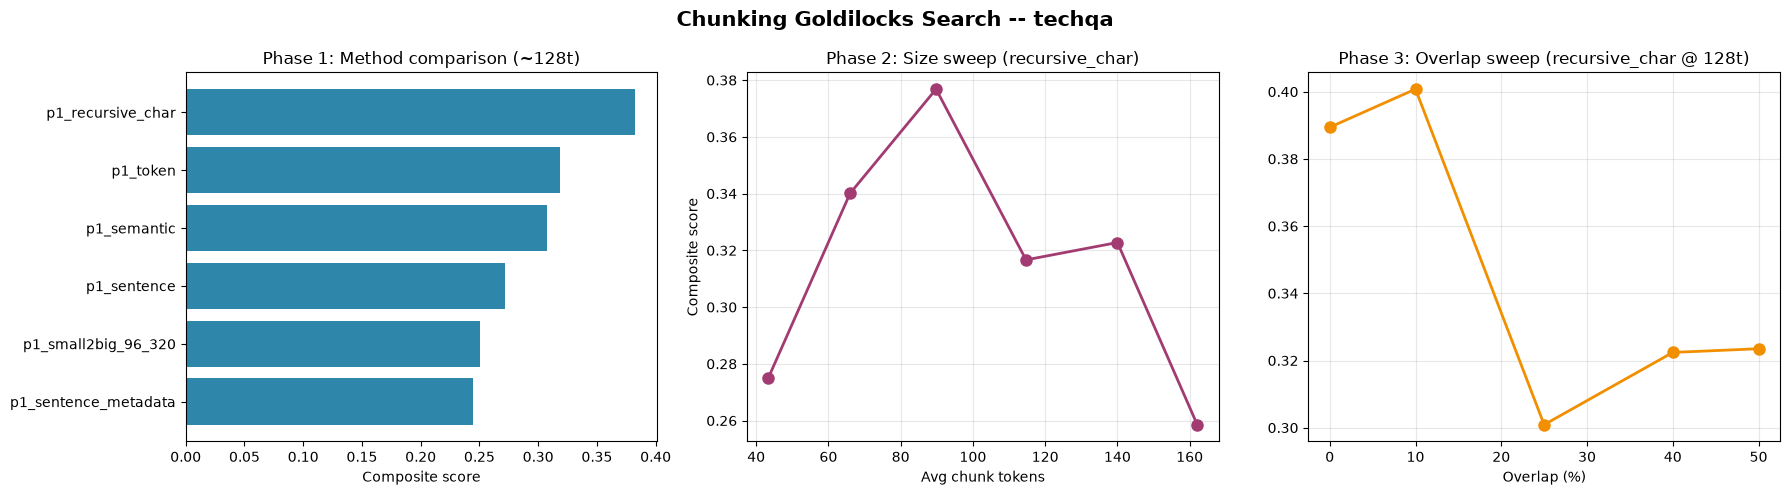

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Chunking Goldilocks Search -- {DATASET_NAME}", fontsize=15, fontweight="bold")

p1_plot = phase1_df.dropna(subset=["composite"]).sort_values("composite")
axes[0].barh(p1_plot["config"], p1_plot["composite"], color="#2E86AB")
axes[0].set_xlabel("Composite score")
axes[0].set_title("Phase 1: Method comparison (~128t)")

p2_plot = phase2_df.dropna(subset=["composite"]).sort_values("avg_chunk_tokens")
axes[1].plot(p2_plot["avg_chunk_tokens"], p2_plot["composite"], "o-", color="#A23B72", linewidth=2, markersize=8)
axes[1].set_xlabel("Avg chunk tokens")
axes[1].set_ylabel("Composite score")
axes[1].set_title(f"Phase 2: Size sweep ({phase1_winner})")
axes[1].grid(True, alpha=0.3)

p3_plot = phase3_df.dropna(subset=["composite"]).copy()
p3_plot["overlap_pct"] = p3_plot["config"].str.extract(r"_ov(\d+)$").astype(int)
p3_plot = p3_plot.sort_values("overlap_pct")
axes[2].plot(p3_plot["overlap_pct"], p3_plot["composite"], "o-", color="#F18F01", linewidth=2, markersize=8)
axes[2].set_xlabel("Overlap (%)")
axes[2].set_title(f"Phase 3: Overlap sweep ({phase1_winner} @ {phase2_winner_size}t)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 11: Final Recommendation

In [16]:
all_results_df = pd.concat([phase1_df, phase2_df, phase3_df], ignore_index=True)
all_results_df = all_results_df.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df[[
    "config", "n_chunks", "avg_chunk_tokens", "n_eval", "n_failed",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

best = all_results_df.iloc[0]
print("\n" + "=" * 100)
print(f"🏆 GOLDILOCKS CONFIG: {best['config']}")
print("=" * 100)
print(f"  Avg chunk tokens:   {best['avg_chunk_tokens']:.0f}")
print(f"  Context Relevance:  {best['context_relevance']:.4f}")
print(f"  Utilization:        {best['utilization']:.4f}")
print(f"  Completeness:       {best['completeness']:.4f}")
print(f"  Adherence:          {best['adherence']:.4f}")
print(f"  Composite:          {best['composite']:.4f}")
print(f"  Eval sample:        {best['n_eval']}/{EVAL_SAMPLE_SIZE} succeeded (failed: {best['n_failed']})")
print("=" * 100)


ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE


,config,n_chunks,avg_chunk_tokens,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
12,p3_recursive_char_128t_ov10,1649,89.8,20,0,0.264510,0.157435,0.497145,0.60,0.400765
13,p3_recursive_char_128t_ov0,1638,88.7,20,0,0.218595,0.136445,0.432955,0.65,0.389418
0,p1_recursive_char,1649,89.8,20,0,0.258765,0.100910,0.327835,0.65,0.382379
6,p2_recursive_char_128t,1649,89.8,20,0,0.218475,0.113970,0.371800,0.65,0.376832
7,p2_recursive_char_96t,2247,66.0,20,0,0.249685,0.132865,0.385220,0.50,0.340102
14,p3_recursive_char_128t_ov50,1906,99.2,20,0,0.196710,0.092435,0.438610,0.50,0.323505
8,p2_recursive_char_192t,1061,140.0,20,0,0.151360,0.091355,0.423850,0.55,0.322757
15,p3_recursive_char_128t_ov40,1805,96.3,20,0,0.267790,0.103105,0.371430,0.45,0.322407
1,p1_token,1342,120.0,20,0,0.183135,0.088930,0.441185,0.50,0.318614
9,p2_recursive_char_160t,1294,114.7,20,0,0.201110,0.095665,0.379365,0.50,0.316643



🏆 GOLDILOCKS CONFIG: p3_recursive_char_128t_ov10
  Avg chunk tokens:   90
  Context Relevance:  0.2645
  Utilization:        0.1574
  Completeness:       0.4971
  Adherence:          0.6000
  Composite:          0.4008
  Eval sample:        20/20 succeeded (failed: 0)


### Caveats -- read before treating this as final

- **Still a single run on one fixed 20-question sample.** Retrying failed annotations and
  reusing the same question set across every config removes *some* noise, but this is one
  dataset draw, not a statistically robust estimate. Bump `EVAL_SAMPLE_SIZE` and/or repeat
  with a different fixed sample before locking a config into production.
- **Embedding model held constant** (`openai/text-embedding-3-small`, `ragbench_lib`
  default). The source paper treats embedding-model choice as coupled to chunking quality
  -- not explored here.
- **Retrieval depth `k` held at 8 throughout.** Chunk size and `k` interact (smaller chunks
  at fixed `k` retrieve less total context) -- that's `04_retriever_optimization.ipynb`'s
  territory, not swept jointly with chunk size here.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, documented above
  so it can be argued with. The raw per-metric columns are in every results table if you
  want to re-rank by a different weighting or a single metric.
